In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
# Load your dataset
df = pd.read_csv("/home/ruthvik/Downloads/Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
# 1. Data Preprocessing:

# Convert categorical features to numerical using one-hot encoding
categorical_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True) # drop_first to avoid multicollinearity

In [4]:
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [5]:
# Select numerical features for PCA (exclude the target variable 'price')
numerical_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking'] + [col for col in df.columns if '_yes' in col] # Include one-hot encoded columns
X = df[numerical_cols]

In [6]:
# 2. Standardization:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [7]:
# 3. PCA:
# Determine the optimal number of components using explained variance ratio
pca = PCA()  # Initialize PCA without specifying n_components to get all components
pca.fit(X_scaled)
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

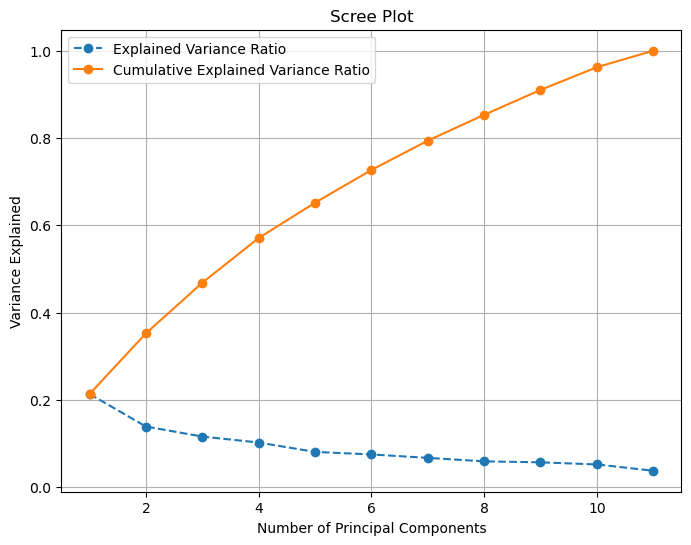

In [8]:
# Scree plot to visualize explained variance
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--', label='Explained Variance Ratio')
plt.plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio, marker='o', linestyle='-', label='Cumulative Explained Variance Ratio')
plt.title('Scree Plot')
plt.xlabel('Number of Principal Components')
plt.ylabel('Variance Explained')
plt.legend()
plt.grid(True)
plt.show()

In [9]:

# Choose the number of components based on the scree plot (e.g., where the explained variance starts to level off or where cumulative variance reaches a desired threshold like 95%)

# Example: Let's say we choose 3 components based on the scree plot
n_components = 3  # You can adjust this based on your scree plot interpretation
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)


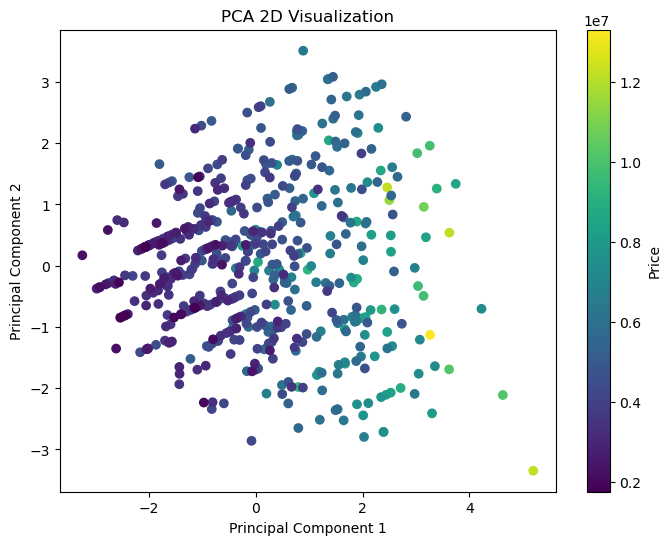

In [10]:

# 4. Data Visualization in Lower Dimensions (2D or 3D):

# 2D Visualization:
if n_components >= 2:
    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['price']) # Color points by 'price' to see how price varies across principal components
    plt.title('PCA 2D Visualization')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.colorbar(label='Price')  # Add a colorbar to show the price scale
    plt.show()



In [11]:

# 3D Visualization (if n_components >= 3):
if n_components >= 3:
    import plotly.express as px
    df_pca = pd.DataFrame(data=X_pca, columns=[f'PC{i+1}' for i in range(n_components)])
    df_pca['price'] = df['price']  # Add the price column for coloring
    fig = px.scatter_3d(df_pca, x='PC1', y='PC2', z='PC3', color='price')
    fig.update_layout(title='PCA 3D Visualization')
    fig.show()


In [12]:

# Interpretation of PCA components:
# Print the loadings (components_) to understand which original features contribute most to each principal component
print("PCA Components (Loadings):")
print(pca.components_) # Each row represents a principal component, and each column represents a feature


#  Example interpretation: If the first principal component has high positive loadings for 'area' and 'bathrooms' and high negative loadings for 'bedrooms',  it might represent a component related to "size and luxury".

PCA Components (Loadings):
[[ 0.3916605   0.36662618  0.3855196   0.33294687  0.31459834  0.26023317
   0.25169849  0.17432922  0.00063369  0.34678731  0.26834727]
 [ 0.16029344 -0.33258121 -0.25491132 -0.4850252   0.0703061   0.21337065
   0.36328609  0.48713927 -0.09861566 -0.08765914  0.35539544]
 [-0.36918927  0.29079572  0.23383559  0.05800206 -0.36928121 -0.44078229
   0.40434575  0.4677328   0.07099524 -0.05050616 -0.02399004]]


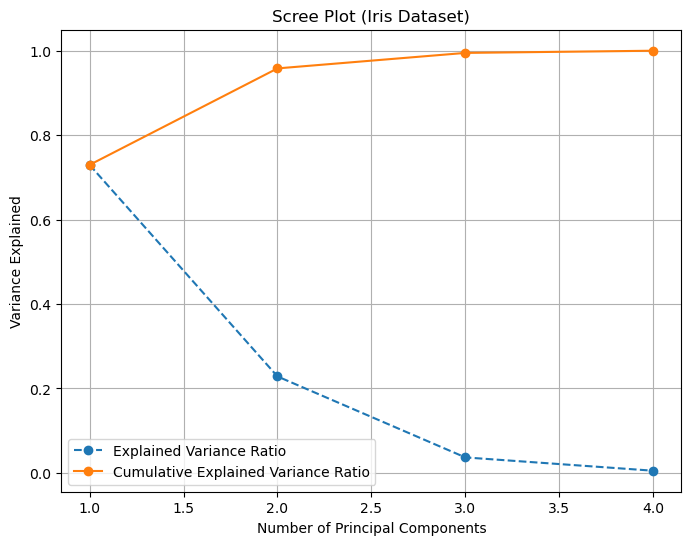

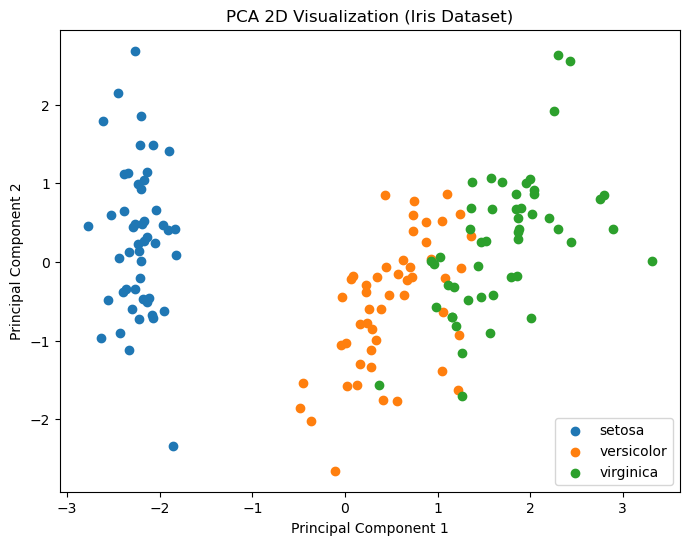

PCA Components (Loadings):
[[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]]


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris


# 1. Load the Iris dataset:
iris = load_iris()
X = iris.data  # Features
y = iris.target # Target variable (species)
feature_names = iris.feature_names
df = pd.DataFrame(data=X, columns=feature_names)
df['species'] = iris.target_names[y] # Add species names to the dataframe

# 2. Standardization:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. PCA:
# Calculate all principal components first to determine the optimal number
pca_all = PCA()
pca_all.fit(X_scaled)
explained_variance_ratio = pca_all.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)


# Scree plot:
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--', label='Explained Variance Ratio')
plt.plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio, marker='o', linestyle='-', label='Cumulative Explained Variance Ratio')
plt.title('Scree Plot (Iris Dataset)')
plt.xlabel('Number of Principal Components')
plt.ylabel('Variance Explained')
plt.legend()
plt.grid(True)
plt.show()


# Choose the number of components (e.g., 2 for easy visualization)
n_components = 2 # You can change this if you want
pca = PCA(n_components=n_components)  
X_pca = pca.fit_transform(X_scaled)

# 4. Visualization:
plt.figure(figsize=(8, 6))
for species in np.unique(y): # Plot each species with a different color
    plt.scatter(X_pca[y == species, 0], X_pca[y == species, 1], label=iris.target_names[species]) 
plt.title('PCA 2D Visualization (Iris Dataset)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()


# Interpret the components:
print("PCA Components (Loadings):")
print(pca.components_)

# Example: If PC1 has high positive loadings for sepal length and sepal width, it suggests that these features contribute strongly to the variation captured by PC1.